# Rung 2 — Walter learns by lowering the loss

**The question this notebook answers:** what does it mean for a machine to *learn*?

In Rung 1, Walter's brain was a table we filled in by counting. Nobody had to "learn" anything; we just tallied pairs. That trick only works because the model is so simple. The moment Walter has to look further back, there are far too many combinations to count.

So now we change the deal. Walter starts with a table of **random numbers**. We show him a letter, he guesses the next one, we measure how wrong he was (the same loss from Rung 1), and we nudge every number a little in the direction that makes him *less* wrong. Then we repeat this hundreds of times.

If learning works, Walter should end up with the same table we counted by hand and land on the same loss, **≈ 2.45**.

Everything here is plain numpy. Every gradient is derived by hand, so nothing is hidden.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

words = open('../data/names.txt').read().splitlines()
chars = sorted(set(''.join(words)))
stoi = {ch: i + 1 for i, ch in enumerate(chars)}
stoi['.'] = 0
itos = {i: ch for ch, i in stoi.items()}
V = len(stoi)  # 27
print(len(words), 'names, vocabulary of', V)

32033 names, vocabulary of 27


## Step 1 — The training set: questions and answers

Learning needs examples of the form *"given this, the answer is that."* Every bigram is one example:

- **input** `x`: the current letter
- **target** `y`: the letter that actually came next

`.emma.` gives five examples: `(. → e)`, `(e → m)`, `(m → m)`, `(m → a)`, `(a → .)`.

In [2]:
xs, ys = [], []
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        xs.append(stoi[ch1])
        ys.append(stoi[ch2])
xs, ys = np.array(xs), np.array(ys)
n = len(xs)
print('number of examples:', n)
print('first five (emma):', [(itos[a], itos[b]) for a, b in zip(xs[:5], ys[:5])])

number of examples: 228146
first five (emma): [('.', 'e'), ('e', 'm'), ('m', 'm'), ('m', 'a'), ('a', '.')]


## Step 2 — Letters become vectors (one-hot encoding)

A neural network multiplies numbers, so the letter ID `5` can't go in as-is: the network would think `e` (5) is "bigger" than `a` (1), which means nothing.

Instead each letter becomes a vector of 27 zeros with a single `1` in its own slot. This is called **one-hot encoding**. Every letter is now equally far from every other letter.

(228146, 27)


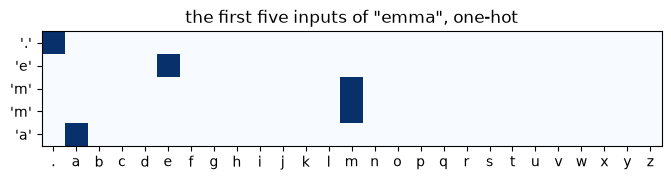

In [3]:
def one_hot(ix, size=V):
    out = np.zeros((len(ix), size))
    out[np.arange(len(ix)), ix] = 1.0
    return out

xenc = one_hot(xs)
print(xenc.shape)
plt.figure(figsize=(8, 2))
plt.imshow(xenc[:5], cmap='Blues')
plt.yticks(range(5), [f"'{itos[i]}'" for i in xs[:5]])
plt.xticks(range(V), [itos[i] for i in range(V)])
plt.title('the first five inputs of "emma", one-hot')
plt.show()

## Step 3 — Walter's new brain: one layer of 27 neurons

Walter is now a single layer of 27 neurons. Each neuron has 27 weights, one per possible input letter, so the whole brain is a 27 × 27 matrix `W` of **weights**, the same shape as the count table.

The forward pass, which is how Walter turns a letter into a guess:

1. `logits = xenc @ W` gives 27 raw scores for the next letter. These can be any real number, positive or negative.
2. `counts = exp(logits)` makes every score positive. Think of these as "fake counts".
3. `probs = counts / counts.sum()` normalises each row so it adds up to 1.

Steps 2 and 3 together are called the **softmax**. Compare this with Rung 1: there we had real counts and normalised them. Here the network *produces* counts, and we normalise them the same way. If Walter learns well, `exp(W)` should end up proportional to the count table `N`.

Note that `xenc @ W` with a one-hot vector just **picks out one row of W**. Multiplying by a one-hot vector is the same as looking a row up. Keep that in mind; it comes back in Rung 3.

In [4]:
rng = np.random.default_rng(seed=2026)
W = rng.standard_normal((V, V))

def forward(W, xs):
    logits = W[xs]                                        # same as one_hot(xs) @ W
    logits = logits - logits.max(axis=1, keepdims=True)   # numerical safety; doesn't change softmax
    counts = np.exp(logits)
    return counts / counts.sum(axis=1, keepdims=True)

def nll(probs, ys):
    return -np.log(probs[np.arange(len(ys)), ys]).mean()

assert np.allclose(one_hot(xs[:100]) @ W, W[xs[:100]])
probs = forward(W, xs)
print('random Walter, loss:', round(nll(probs, ys), 4), '(uniform guessing would be', round(np.log(V), 4), ')')

random Walter, loss: 3.7791 (uniform guessing would be 3.2958 )


A random Walter is *worse* than uniform guessing. That makes sense: random weights make him confident about random letters, and being confidently wrong is punished hard by the log.

## Step 4 — Which way is downhill? The gradient

The loss is a function of 729 numbers (the weights). We want to know, for each weight: *"if I increase you a tiny bit, does the loss go up or down, and by how much?"* That number is the **gradient** of the loss with respect to that weight.

For softmax followed by negative log likelihood there is a beautiful closed form. For one example with target `y`:

$$\frac{\partial\, \text{loss}}{\partial\, \text{logit}_j} = p_j - [j = y]$$

In words: **push every wrong letter's score down by how much probability it stole, and push the right letter's score up by how much probability it was missing.** If Walter put probability 1 on the correct letter, the gradient is zero and there is nothing to fix.

Since `logits = xenc @ W`, the chain rule gives `dW = xenc.T @ dlogits`. Each row of `W` collects the gradient from the examples whose input was that letter.

In [5]:
def loss_and_grad(W, xs, ys, reg=0.0):
    probs = forward(W, xs)
    loss = nll(probs, ys) + reg * (W ** 2).mean()
    dlogits = probs.copy()
    dlogits[np.arange(len(ys)), ys] -= 1          # p_j - [j == y]
    dlogits /= len(ys)                            # because the loss is a mean
    # dW = one_hot(xs).T @ dlogits: each row of W collects the gradients of the examples
    # whose input was that letter. bincount does the same sum without building the big matrix.
    dW = np.stack([np.bincount(xs, weights=dlogits[:, j], minlength=V) for j in range(V)], axis=1)
    dW += reg * 2 * W / W.size
    return loss, dW

## Step 5 — Never trust a hand-derived gradient: check it

A gradient is just a slope. We can estimate a slope with no calculus at all: nudge one weight by a tiny `h`, re-measure the loss, and compute `(loss(w + h) − loss(w − h)) / 2h`. That's slow (two full passes *per weight*), but it's a perfect lie detector for the formula above.

In [6]:
sub_x, sub_y = xs[:2000], ys[:2000]
_, dW = loss_and_grad(W, sub_x, sub_y)

h = 1e-5
worst = 0.0
for _ in range(10):
    i, j = rng.integers(V), rng.integers(V)
    Wp, Wm = W.copy(), W.copy()
    Wp[i, j] += h
    Wm[i, j] -= h
    numeric = (nll(forward(Wp, sub_x), sub_y) - nll(forward(Wm, sub_x), sub_y)) / (2 * h)
    worst = max(worst, abs(numeric - dW[i, j]))
    print(f'W[{itos[i]},{itos[j]}]  formula {dW[i, j]: .8f}   nudge-and-measure {numeric: .8f}')
print('largest disagreement:', worst)

W[g,n]  formula  0.00036340   nudge-and-measure  0.00036340
W[r,q]  formula  0.00024212   nudge-and-measure  0.00024212
W[o,y]  formula  0.00189533   nudge-and-measure  0.00189533
W[p,m]  formula  0.00031452   nudge-and-measure  0.00031452
W[a,f]  formula  0.00549865   nudge-and-measure  0.00549865
W[l,y]  formula -0.00026658   nudge-and-measure -0.00026658
W[n,a]  formula -0.01486364   nudge-and-measure -0.01486364
W[e,o]  formula  0.00006235   nudge-and-measure  0.00006235
W[c,y]  formula -0.00005561   nudge-and-measure -0.00005561
W[e,t]  formula -0.00259594   nudge-and-measure -0.00259594
largest disagreement: 2.6040347721016655e-11


They agree to many decimal places, so the formula is right.

## Step 6 — Gradient descent: walk downhill

Training is now a loop of three lines:

1. **forward**: compute the loss
2. **backward**: compute the gradient
3. **update**: `W -= learning_rate * dW`, a small step downhill

The learning rate here is large (50) because this problem is very smooth, and our gradients are tiny since they are averaged over 228,000 examples.

step   0  loss 3.6302


step  50  loss 2.4985


step 100  loss 2.4736


step 150  loss 2.4661


step 200  loss 2.4627


step 250  loss 2.4607


step 299  loss 2.4594


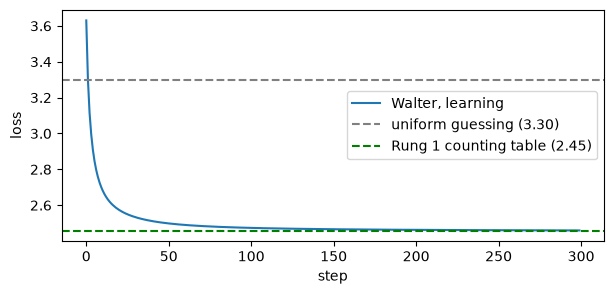

In [7]:
N = np.zeros((V, V))
np.add.at(N, (xs, ys), 1)                         # Rung 1's count table, for comparison
P_counted = (N + 1) / (N + 1).sum(axis=1, keepdims=True)
counted_loss = -np.log(P_counted[xs, ys]).mean()

W = rng.standard_normal((V, V))
losses = []
for step in range(300):
    loss, dW = loss_and_grad(W, xs, ys)
    W -= 50 * dW
    losses.append(loss)
    if step % 50 == 0 or step == 299:
        print(f'step {step:3d}  loss {loss:.4f}')

plt.figure(figsize=(7, 3))
plt.plot(losses, label='Walter, learning')
plt.axhline(np.log(V), color='gray', ls='--', label='uniform guessing (3.30)')
plt.axhline(counted_loss, color='green', ls='--', label=f'Rung 1 counting table ({counted_loss:.2f})')
plt.xlabel('step'); plt.ylabel('loss'); plt.legend(); plt.show()

Walter starts out worse than random, falls fast, and then flattens out just above the counting table's loss.

## Step 7 — Did Walter rediscover the table?

Here is the real test. Turn Walter's weights back into probabilities with `softmax(W)` and put them next to the probabilities we counted in Rung 1.

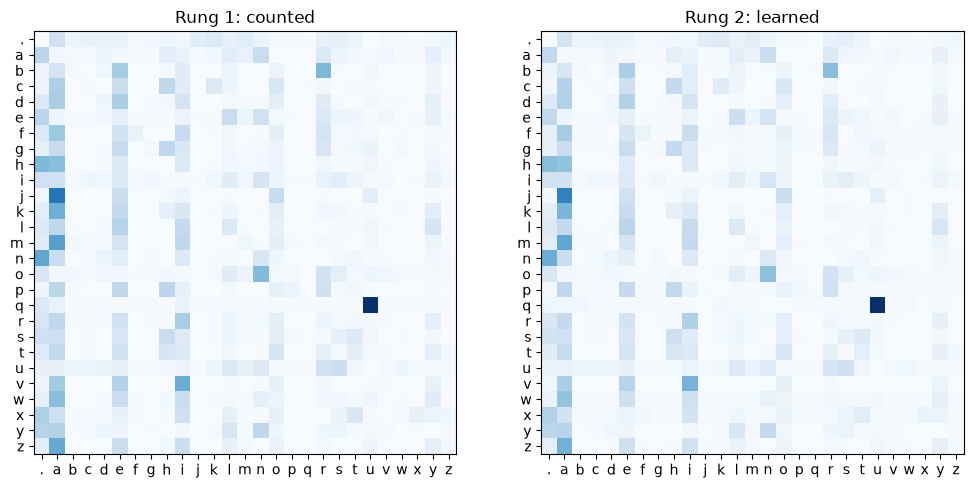

biggest difference between the two tables: 0.0656
P(u | q)   counted +1 smoothing: 0.692   counted, no smoothing: 0.757   learned: 0.738


In [8]:
P_learned = forward(W, np.arange(V))

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
for a, M, title in zip(ax, [P_counted, P_learned], ['Rung 1: counted', 'Rung 2: learned']):
    a.imshow(M, cmap='Blues')
    a.set_xticks(range(V)); a.set_xticklabels([itos[i] for i in range(V)])
    a.set_yticks(range(V)); a.set_yticklabels([itos[i] for i in range(V)])
    a.set_title(title)
plt.show()

print('biggest difference between the two tables:', np.abs(P_counted - P_learned).max().round(4))
P_raw = N / N.sum(axis=1, keepdims=True)
print("P(u | q)   counted +1 smoothing:", P_counted[stoi['q'], stoi['u']].round(3),
      "  counted, no smoothing:", P_raw[stoi['q'], stoi['u']].round(3),
      "  learned:", P_learned[stoi['q'], stoi['u']].round(3))

Two completely different processes, **counting** and **learning**, arrive at the same picture. They're close but not identical: Walter's `P(u | q)` sits between the smoothed and unsmoothed counts, because nothing in his training is doing the `+1` yet (Step 8 fixes that).
 Walter was never told that `q` goes to `u`. He worked it out by making mistakes and adjusting.

## Step 8 — Smoothing has a twin: regularisation

In Rung 1 we added 1 to every count so nothing became impossible. The neural-net version is to add a penalty for large weights to the loss: `reg * mean(W²)`. This pulls every weight towards 0, and `W = 0` means *all letters equally likely*, so the penalty pulls Walter gently towards uniform, which is exactly what fake counts did.

More regularisation works like more smoothing. Below, as each knob is turned up, Walter's opinions flatten out (`P(u | q)` drops) and the loss on the data rises a little, in both worlds. The two knobs are on different scales, but they do the same job.

In [9]:
def train(reg, steps=300):
    W = np.zeros((V, V))
    for _ in range(steps):
        _, dW = loss_and_grad(W, xs, ys, reg=reg)
        W -= 50 * dW
    return W

print('neural net, weight penalty          counting, fake counts')
for reg, fake in [(0.0, 0), (0.01, 1), (0.1, 10)]:
    Pr = forward(train(reg), np.arange(V))
    Ps = (N + fake) / (N + fake).sum(axis=1, keepdims=True)
    with np.errstate(divide='ignore'):
        smooth_loss = -np.log(Ps[xs, ys]).mean()
    print(f'reg {reg:4.2f}: loss {nll(Pr[xs], ys):.4f}  P(u|q) {Pr[stoi["q"], stoi["u"]]:.3f}     '
          f'+{fake:<3d}: loss {smooth_loss:.4f}  P(u|q) {Ps[stoi["q"], stoi["u"]]:.3f}')

neural net, weight penalty          counting, fake counts


reg 0.00: loss 2.4589  P(u|q) 0.733     +0  : loss 2.4540  P(u|q) 0.757


reg 0.01: loss 2.4626  P(u|q) 0.657     +1  : loss 2.4546  P(u|q) 0.692


reg 0.10: loss 2.5033  P(u|q) 0.263     +10 : loss 2.4621  P(u|q) 0.399


## Step 9 — Walter speaks again

Sampling works exactly like Rung 1: start at `.`, roll the weighted die, move on. Walter is the same model, so expect the same kind of bad names.

In [10]:
gen = np.random.default_rng(seed=2026)
for _ in range(10):
    out, ix = [], 0
    while True:
        ix = gen.choice(V, p=P_learned[ix])
        if ix == 0:
            break
        out.append(itos[ix])
    print(''.join(out))

ciieirtan
ysionnah
chan
ja
leeatrieyleten
dialiarinajalima
ride
tz
gmanaryriay
eena


## Step 10 — Handing the calculus to a machine (PyTorch)

Deriving `p − onehot(y)` by hand was fine for one layer. From Rung 3 on, Walter will have several layers, embeddings and eventually attention, and deriving every gradient by hand gets long and error-prone.

**PyTorch** does the chain rule automatically. Every operation remembers how it was computed, and `loss.backward()` walks that record backwards. This is called *autograd*. Before relying on it, we make it pass the same test as our formula: it must produce **exactly the gradient we derived by hand**.

In [11]:
import torch

Wt = torch.tensor(W, requires_grad=True)
xt, yt = torch.tensor(xs), torch.tensor(ys)
logits = Wt[xt]
loss_t = torch.nn.functional.cross_entropy(logits, yt)   # softmax + negative log likelihood in one call
loss_t.backward()

loss_np, dW_np = loss_and_grad(W, xs, ys)
print('loss     numpy:', round(loss_np, 6), '  torch:', round(loss_t.item(), 6))
print('largest gradient difference:', np.abs(Wt.grad.numpy() - dW_np).max())

loss     numpy: 2.459395   torch: 2.459395
largest gradient difference: 3.328552550298518e-16


They are identical up to floating-point noise. From here on we let PyTorch handle the derivatives, because we know what it is doing underneath.

## What just happened

1. **Examples**: every bigram became a question (`x`) and an answer (`y`).
2. **One-hot**: letters became vectors a network can multiply.
3. **Forward pass**: `logits → exp → normalise` (softmax) turns weights into probabilities.
4. **Gradient**: `p − onehot(y)` tells every weight which way is downhill. We checked it by nudging.
5. **Gradient descent**: many small steps downhill took Walter from random to the counting table.
6. **Regularisation** turned out to be smoothing in disguise.

The headline result is that **learning by gradient descent rediscovered the counted table** (≈ 2.45 vs 2.45). The neural net wasn't better, and it couldn't be: the table was already the best any one-letter model can do. What we gained is a *method* that keeps working when counting becomes impossible.

## Your turn (do these before Rung 3)
- Change the learning rate to 1, then 500. What happens to the loss curve, and why?
- In Step 5, set `h = 1e-12`. Why does the check get *worse* with a smaller nudge?
- Start `W` at zeros instead of random. Where does the loss start? (Hint: what is `softmax` of all zeros?)
- Why is the loss stuck just above 2.45 and never below it?

**Next — Rung 3:** Walter learns to look **three** letters back. A count table for that would have 27³ = 19,683 rows, most of them empty. A neural network with *embeddings* sidesteps the problem.